In [136]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import run_fair

import utils_MLP

import xarray as xr

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Notebook for generating all sets of training, validation, test data for a NN emulator of FaIR

#### 1. ScenarioMIP for CMIP7
ScenarioMIP for CMIP7 consists of a set of scenarios that represent plausible future emissions pathways separated into sets by priority, either high (tier 1) and low (tier 2). Although all scenarios are requested to be run from 2025-2150, each scenario also has a long-term extension from 2150-2500; there is also a <i> historical </i> scenario using historical emissions data from 1750-2024 (FaIR specifically runs starting at 1750, while ESMs typically start in 1850). Only two extensions are part of tier 1: the <i>High</i> and <i> Very Low with Limited Overshoot. </i> For this work, we consider only emissions-driven scenarios, and the full list of scenarios is below.

<ol>
  <li> Tier 1</li>
  <ol>
    <li> High w/ Extension (H-ext) </li>
    <li> Medium (M) </li>
    <li> Medium-Low (ML) </li>
    <li> Low (L) </li>
    <li> Very Low with Limited Overshoot w/ Extension (VLLO-ext)</li>
    <li> Very Low after High Overshoot (VLHO)</li>
  </ol>
  <li> Tier 2</li>
  <ol>
    <li> High Overshoot w/ Extension (H-ext-OS) </li>
    <li> Medium w/ Extension (M-ext) </li>
    <li> Medium-Low w/ Extension (ML-ext) </li>
    <li> Low w/ Extension (L-ext) </li>
    <li> Very Low after High Overshoot w/ Extension (VLHO-ext) </li>
  </ol>
</ol>

We split these data as follows: (1) We use tier 1 scenarios to train our baseline emulator based on the assumption that all modeling centers will run these scenarios. (2) Also based on this assumption, we use tier 1 scenarios as the target of our Bayesian optimization to find the optimal parameter set for our theoretically optimal emulator training scenario. (3) We then test both emulators against the full set of tier 2 scenarios.

In [63]:
# Generate tier 1 and tier 2 scenarios
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())

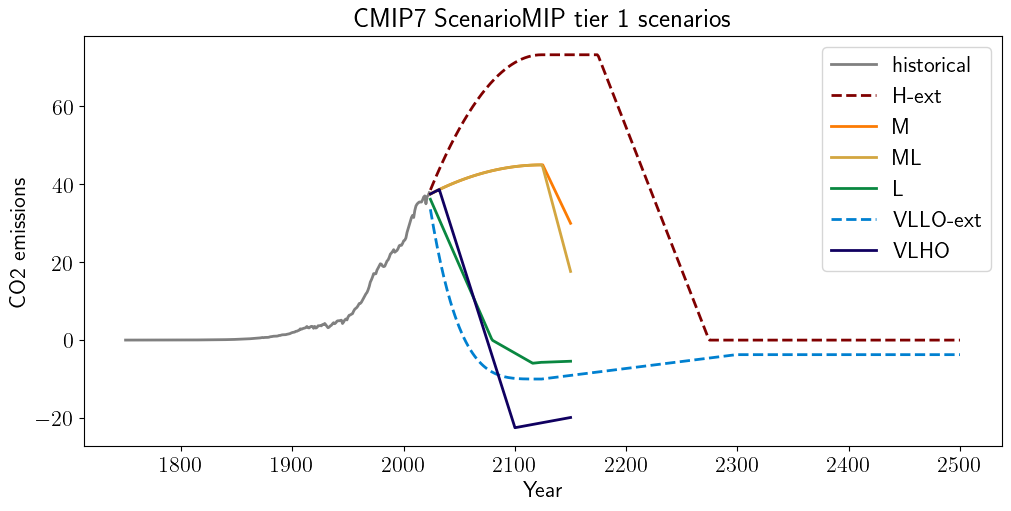

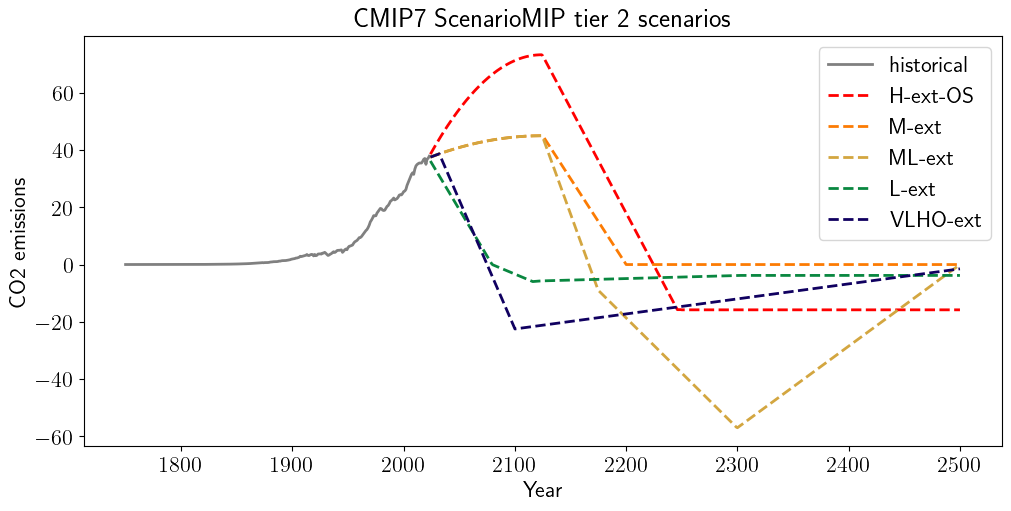

In [209]:
# Plot emissions scenarios (optional)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_tier1, agent, 'ScenarioMIP tier 1')
run_fair.plot_emissions(emis_dict_tier2, agent, 'ScenarioMIP tier 2')

In [79]:
# Run FaIR for each scenario to get temperature change
delT_dict_tier1 = run_fair.get_cmip7_delT(emis_dict_tier1, scenarios_tier1, agents)
delT_dict_tier2 = run_fair.get_cmip7_delT(emis_dict_tier2, scenarios_tier2, agents)

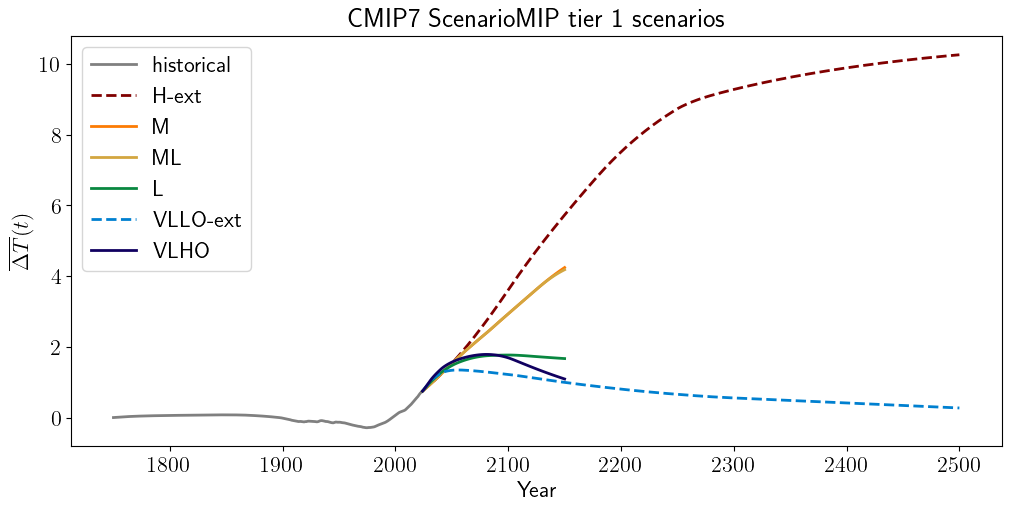

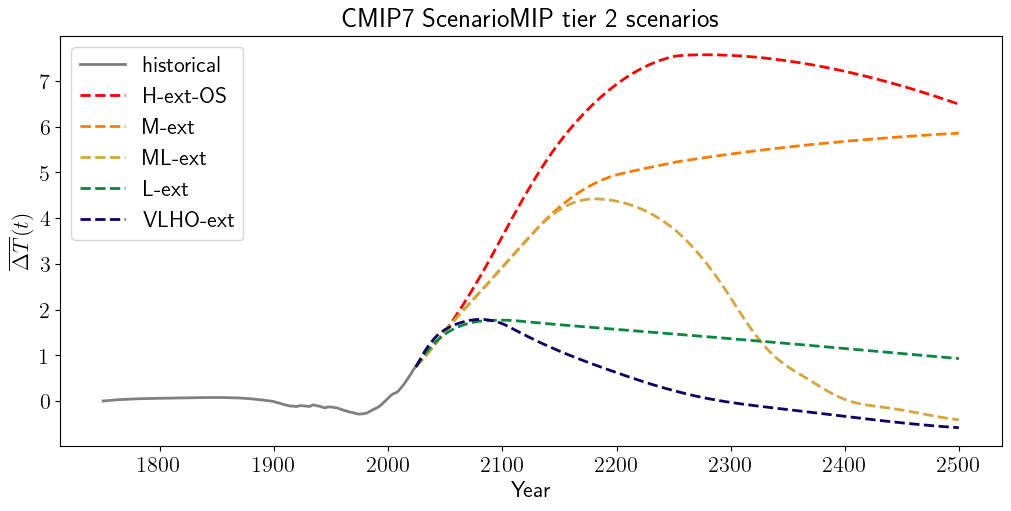

In [245]:
# Plot temperature change (optional)
run_fair.plot_cmip7_delT(delT_dict_tier1, scenarios_tier1, 'ScenarioMIP tier 1')
run_fair.plot_cmip7_delT(delT_dict_tier2, scenarios_tier2, 'ScenarioMIP tier 2')

In [93]:
# Create MLP and evaluate on tier 2 experiments (training on individual scenarios)
series_tier1, series_tier2 = [], []
for scen in scenarios_tier1:
  series_tier1.append((emis_dict_tier1[scen], delT_dict_tier1[scen]))
for scen in scenarios_tier2:
  series_tier2.append((emis_dict_tier2[scen], delT_dict_tier2[scen]))

error_dict_single, yhat_dict_single = utils_MLP.evaluate_trainsets_vs_tests_with_history(scenarios_tier1, series_tier1, scenarios_tier2, series_tier2, agents, n_lags=10, random_state=0)

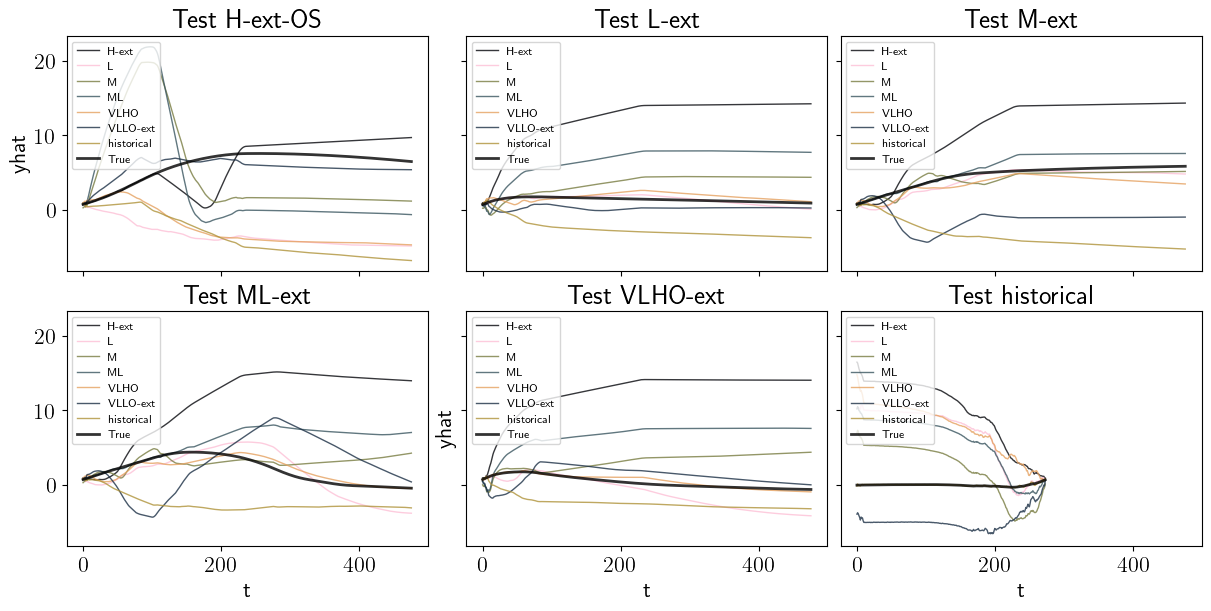

In [94]:
# Plot predictions (optional)
utils_MLP.plot_yhats_grid(error_dict_single, yhat_dict_single, delT_dict_tier2)

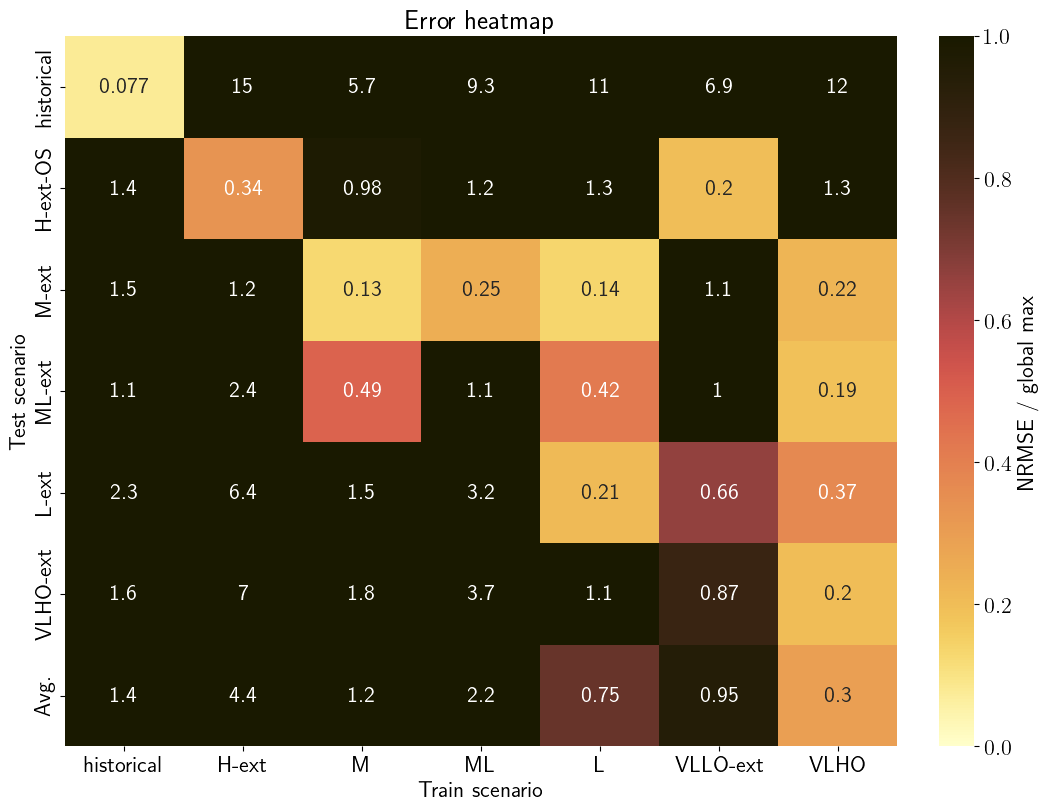

In [95]:
# Plot error heatmap (optional)
utils_MLP.plot_error_heatmap(error_dict_single, scenarios_tier1, scenarios_tier2)

In [96]:
# Create MLP and evaluate on tier 2 experiments (training on multiple scenarios)
training_groups = {'Bracket':['H-ext','VLLO-ext']}
training_groups['All_CMIP7'] = scenarios_tier1.copy()

for scen in scenarios_tier1:
  key = f'Hold_{scen}'
  value = [tag for tag in scenarios_tier1 if tag != scen]
  training_groups[key] = value

error_dict_multi, yhat_dict_multi = utils_MLP.evaluate_trainsets_vs_tests_with_history(scenarios_tier1, series_tier1, scenarios_tier2, series_tier2, training_groups=training_groups, n_lags=10, random_state=0)

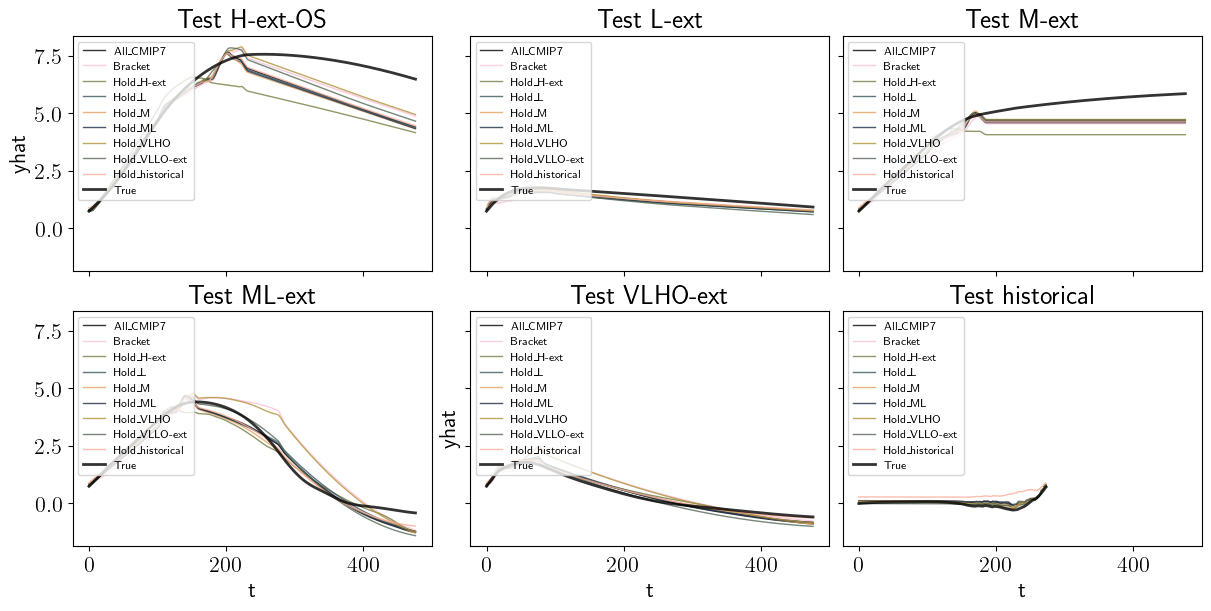

In [97]:
# Plot predictions (optional)
utils_MLP.plot_yhats_grid(error_dict_multi, yhat_dict_multi, delT_dict_tier2)

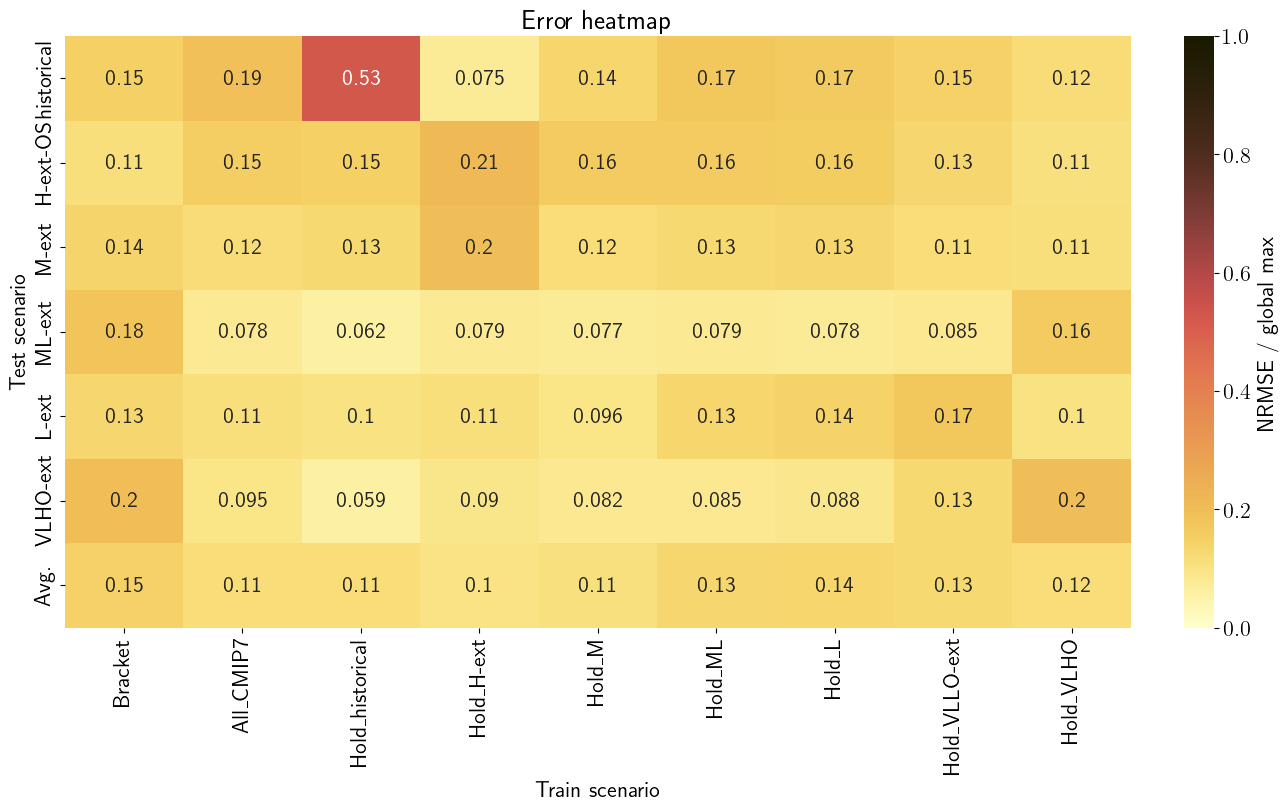

In [99]:
# Plot error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_MLP.plot_error_heatmap(error_dict_multi, scenarios_train_multi, scenarios_tier2)

#### 2. DECK for CMIP7, includes custom scenarios

In [236]:
# Generate DECK scenarios (includes custome scenarios e.g. abrupt-4xCH4)
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())

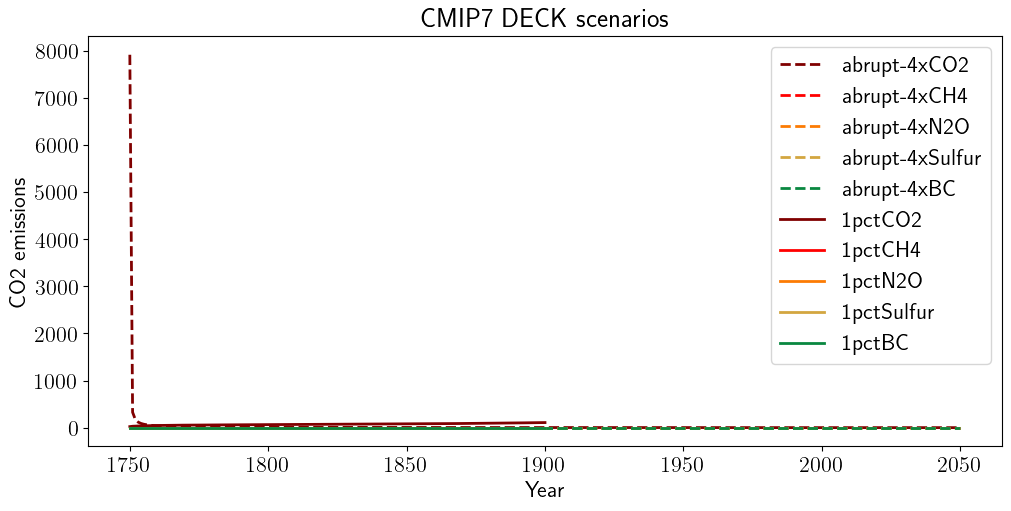

In [242]:
# Plot emissions scenarios (optional; sanity check, most emissions should = 0)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_DECK, agent, 'DECK', DECK=True)

In [239]:
# Run FaIR for each scenario to get temperature change
delT_dict_DECK = run_fair.get_cmip7_delT(emis_dict_DECK, scenarios_DECK, agents, DECK=True)

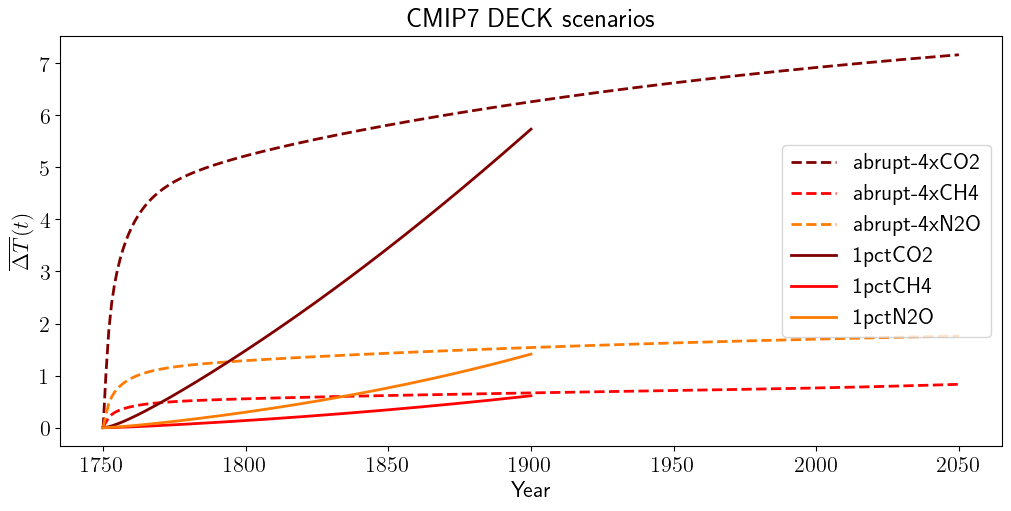

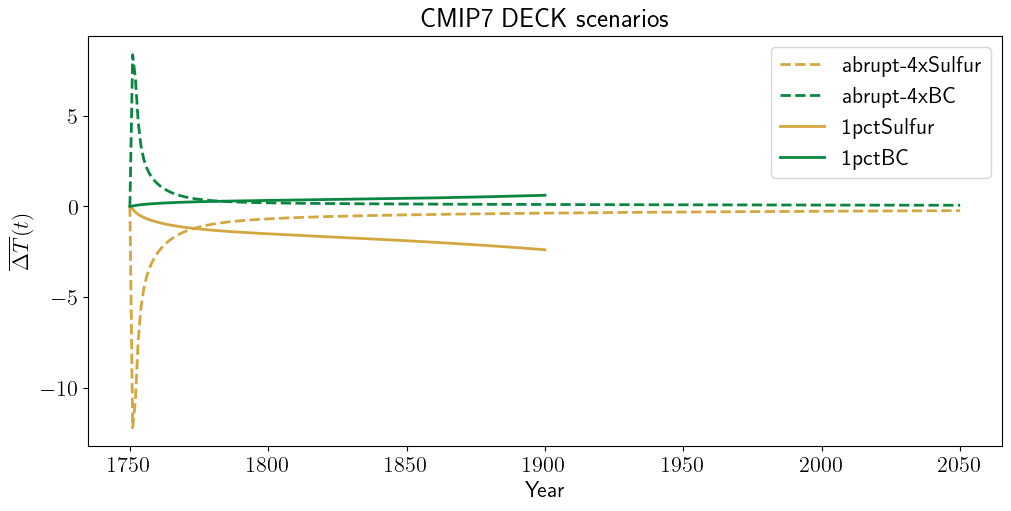

In [249]:
# Plot temperature change (optional)
well_mixed = ['abrupt-4xCO2','abrupt-4xCH4','abrupt-4xN2O',
              '1pctCO2','1pctCH4','1pctN2O']
aerosols = ['abrupt-4xSulfur','abrupt-4xBC',
            '1pctSulfur','1pctBC']
run_fair.plot_cmip7_delT(delT_dict_DECK, well_mixed, 'DECK', DECK=True)
run_fair.plot_cmip7_delT(delT_dict_DECK, aerosols, 'DECK', DECK=True)

In [250]:
# Evaluate MLP on DECK experiments (training on multiple scenarios)
series_DECK = []
for scen in scenarios_DECK:
  series_DECK.append((emis_dict_DECK[scen], delT_dict_DECK[scen]))

error_dict_DECK_multi, yhat_dict_DECK_multi = utils_MLP.evaluate_trainsets_vs_tests_with_history(scenarios_tier1, series_tier1, scenarios_DECK, series_DECK, training_groups=training_groups, n_lags=10, random_state=0)

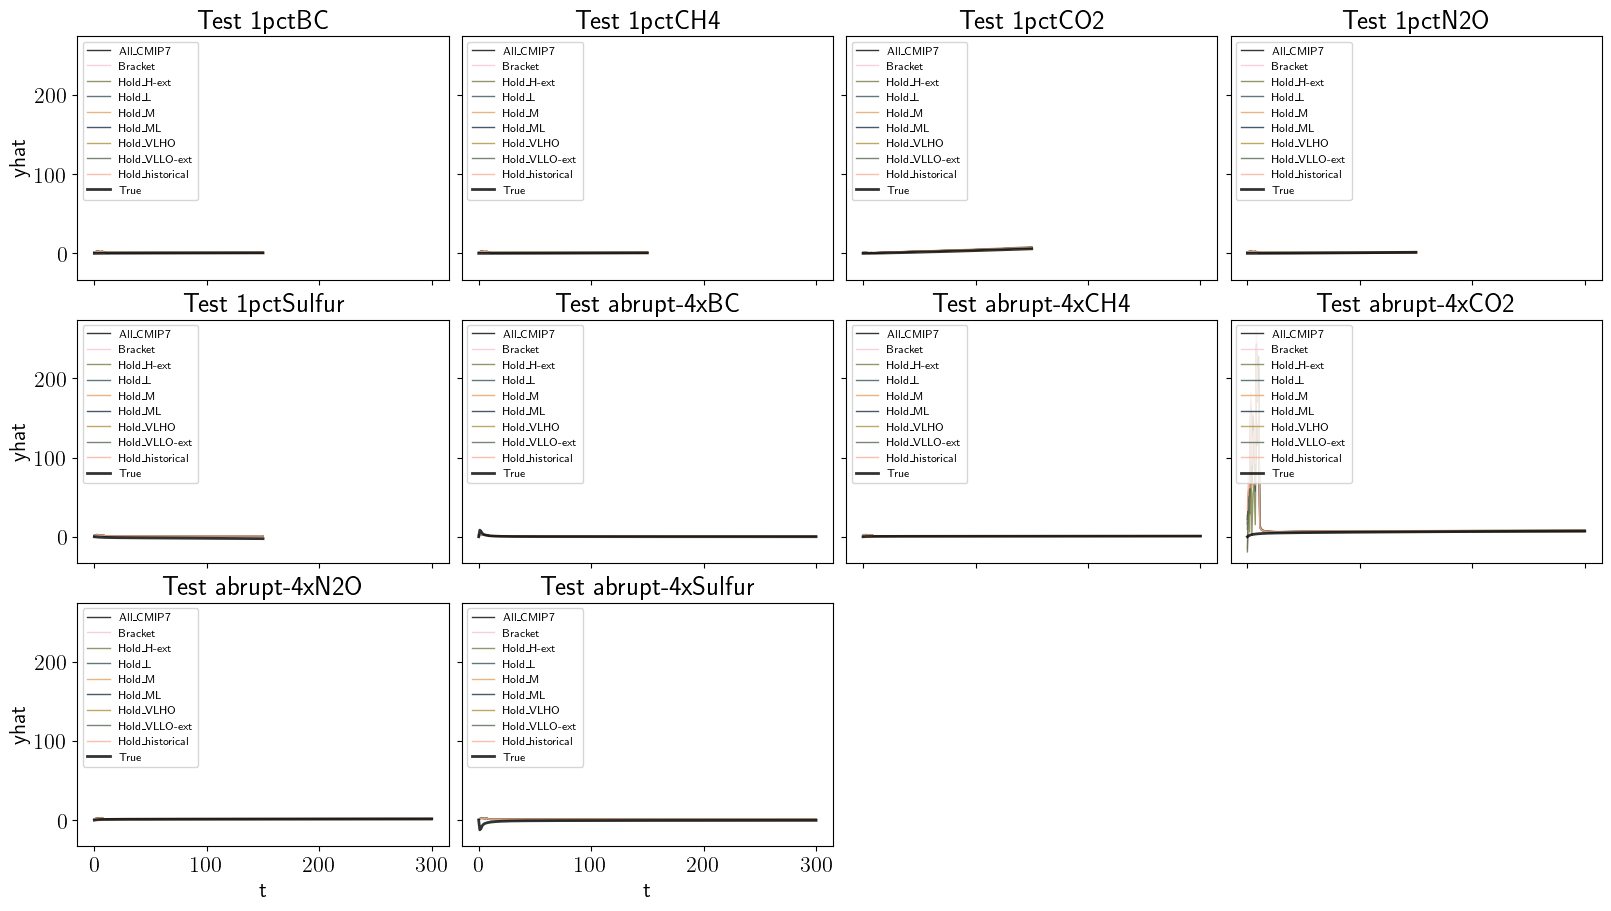

In [251]:
# Plot predictions (optional)
utils_MLP.plot_yhats_grid(error_dict_DECK_multi, yhat_dict_DECK_multi, delT_dict_DECK)

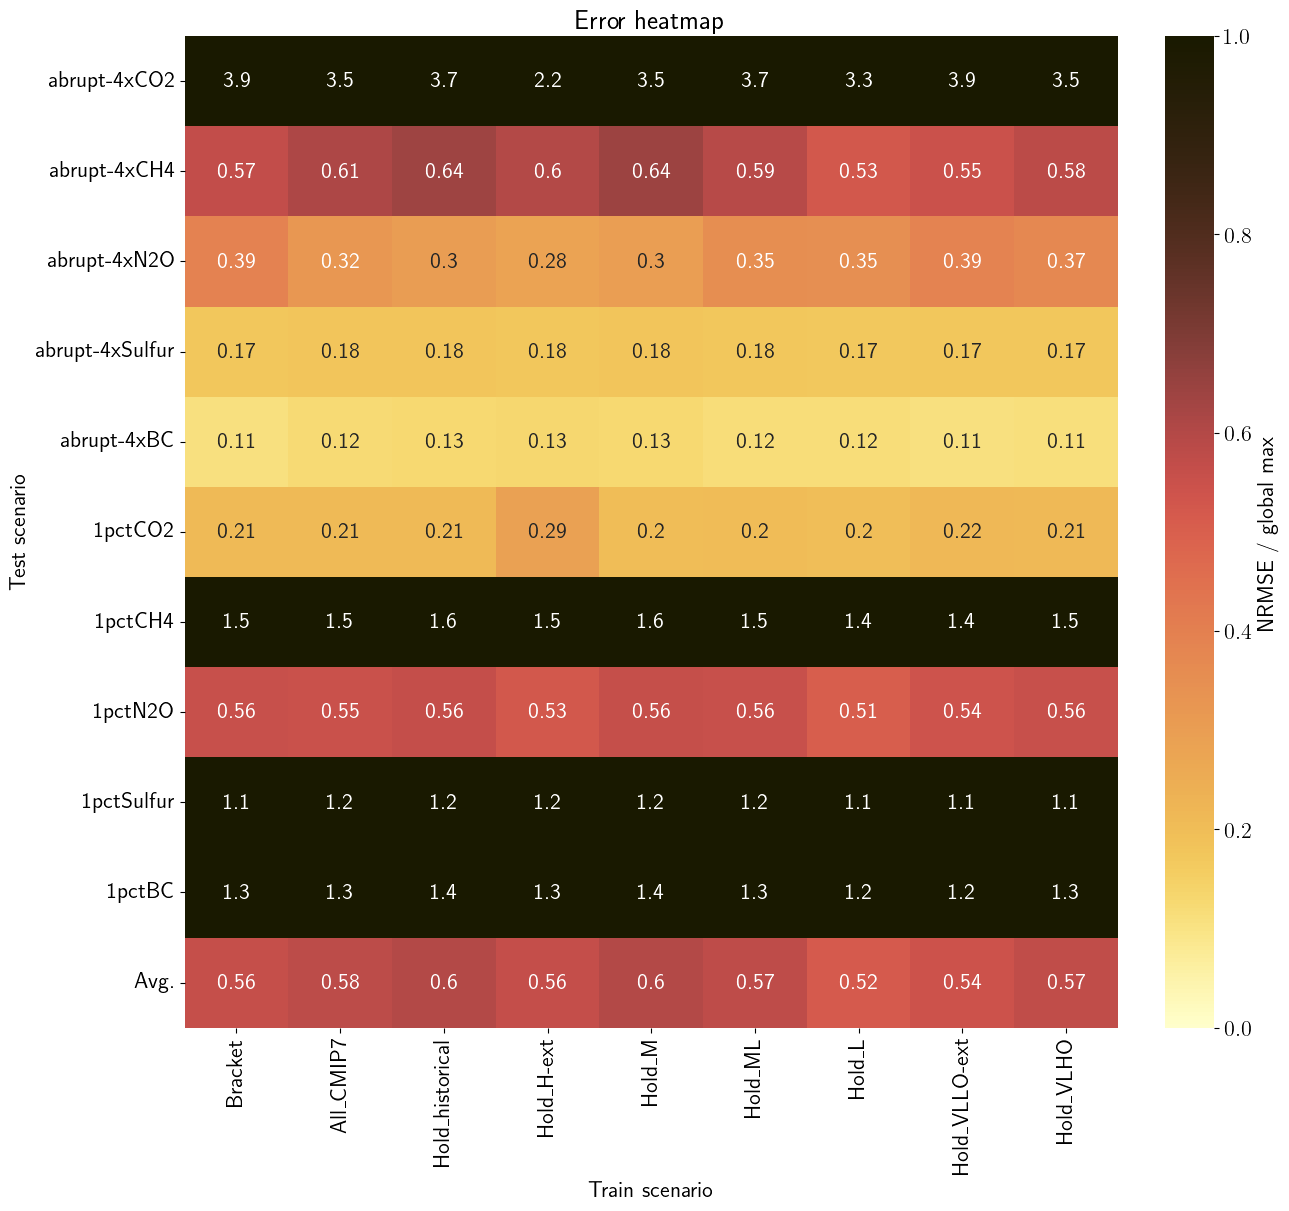

In [252]:
# Plot error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_MLP.plot_error_heatmap(error_dict_DECK_multi, scenarios_train_multi, scenarios_DECK)

#### X. GeoMIP for CMIP6

#### X. CDRMIP for CMIP6

#### X. DAMIP for CMIP6

#### X. Custom scenarios from the MIT Center for Sustainability Science and Strategy (CS3) - Current Trends (CT) and Accelerated Actions (AA)